# 02 — Pipeline Bronze→Silver→Gold, KPIs e Insights

Proyecto **CRM + Billing + Universidad** — documentación técnica del pipeline implementado y análisis de negocio sobre la capa Gold.

**Fecha de análisis:** 2026-07-20 (snapshot) · Datos operativos 2022–2025

Este notebook complementa a `01_discovery.ipynb` (perfilado de los CSV crudos). Aquí:

1. **Fuentes y trazabilidad** — qué se ingirió y con qué evidencia.
2. **El pipeline por dentro** — las tres capas en PostgreSQL y su orquestación con Airflow.
3. **Calidad materializada** — cómo cada hallazgo del discovery se volvió una columna consultable.
4. **KPIs** — las 7 vistas de negocio de Gold.
5. **Insights** ⭐ — hallazgos accionables, cada número calculado en vivo contra la base.
6. **Conclusiones y mejoras futuras.**

> Todos los números de este notebook se **recalculan al ejecutarlo** (queries contra PostgreSQL); fueron además verificados de forma independiente durante la minería de insights (`docs/insights.md`).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

URL = (f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
       f"@{os.environ.get('POSTGRES_HOST', 'postgres')}:5432/{os.environ['POSTGRES_DB']}")
engine = create_engine(URL)

def q(sql):
    """Ejecuta una query y devuelve un DataFrame."""
    return pd.read_sql(sql, engine)

pd.options.display.float_format = '{:,.2f}'.format
print('Conectado a', engine.url.host, '/', engine.url.database)

Conectado a postgres / datawarehouse


## 1. Fuentes de datos y trazabilidad de la ingesta

Tres sistemas de origen sobre el mismo negocio: **university** (académico), **billing** (facturación de suscripciones) y **crm** (comercial). 18 archivos CSV, 446.708 filas.

La tabla de control `bronze.ingestion_batches` registra cada carga con checksum SHA-256, conteos esperados/cargados y estado — la evidencia de que la ingesta fue completa e idempotente:

In [2]:
batches = q('''
    SELECT source_domain, source_table, expected_rows, loaded_rows, status,
           left(source_checksum, 12) AS checksum_prefix
    FROM bronze.ingestion_batches
    ORDER BY source_domain, source_table''')
print(f"Batches: {len(batches)} | success: {(batches.status == 'success').sum()} "
      f"| filas cargadas: {batches.loaded_rows.sum():,}")
batches

Batches: 18 | success: 18 | filas cargadas: 446,708


,source_domain,source_table,expected_rows,loaded_rows,status,checksum_prefix
0,billing,customers,10000,10000,success,381bae54e382
1,billing,invoice_items,150000,150000,success,69cef4e620e3
2,billing,invoices,50000,50000,success,718588ee6f94
3,billing,payments,80000,80000,success,2ce28a832608
4,billing,products,200,200,success,e6599bda14de
5,billing,subscriptions,15000,15000,success,1f8144e429aa
6,crm,accounts,5000,5000,success,b2df49f4b73a
7,crm,activities,20000,20000,success,667f6fd396e8
8,crm,contacts,15000,15000,success,e622d47f0702
9,crm,leads,2000,2000,success,f7df2f976802


**Lectura:** 18/18 batches en `success`, 446.708/446.708 filas reconciliadas. Si un CSV cambiara, su checksum crearía un batch nuevo sin sobrescribir la evidencia anterior.

## 2. El pipeline por dentro: Bronze → Silver → Gold

| Capa | Rol | Regla central |
|---|---|---|
| **Bronze** | Copia fiel del CSV (todo `TEXT`) + metadatos de ingesta | Nada se transforma; todo se puede auditar |
| **Silver** | Tipos reales + estandarización + **flags de calidad** | *Preservar + flaggear + derivar, nunca sobrescribir* |
| **Gold** | Modelo estrella (7 dims + 7 hechos) + vistas KPI | Definiciones de negocio inequívocas |

La orquestación es un DAG de Airflow (`pipeline_medallion`) donde **el validador de cada capa actúa como gate**: si una validación falla, el pipeline se detiene antes de propagar datos malos.

```
validar_fuentes → bronze (paralelo × 3 dominios) → validar_bronze
   → silver → validar_silver → gold → validar_gold
   → exportar_parquet → validar_parquet
```

Inventario real de las tres capas en PostgreSQL:

In [3]:
inventario = q('''
    SELECT table_schema AS capa, table_type AS tipo, count(*) AS objetos
    FROM information_schema.tables
    WHERE table_schema IN ('bronze', 'silver', 'gold')
    GROUP BY 1, 2 ORDER BY 1, 2''')
display(inventario)

conteos = q('''
    SELECT 'bronze (filas fuente)' AS medida, sum(loaded_rows)::bigint AS valor
      FROM bronze.ingestion_batches
    UNION ALL SELECT 'silver.university_enrollments', count(*) FROM silver.university_enrollments
    UNION ALL SELECT 'gold.fact_enrollment (supervivientes)', count(*) FROM gold.fact_enrollment
    UNION ALL SELECT 'gold.fact_invoice', count(*) FROM gold.fact_invoice''')
conteos

,capa,tipo,objetos
0,bronze,BASE TABLE,19
1,gold,BASE TABLE,14
2,gold,VIEW,7
3,silver,BASE TABLE,19


,medida,valor
0,bronze (filas fuente),446708
1,gold.fact_enrollment (supervivientes),24977
2,silver.university_enrollments,25000
3,gold.fact_invoice,50000


**Lectura:** Bronze y Silver conservan las 446.708 filas (nada se borra); Gold filtra con reglas explícitas (p. ej. `fact_enrollment` usa las 24.977 inscripciones supervivientes del dedupe — los 23 duplicados lógicos quedan marcados en Silver, no eliminados).

## 3. Calidad materializada: del hallazgo a la columna

El discovery encontró un dataset *estructuralmente perfecto* (0 huérfanos, 0 PKs duplicadas) pero *semánticamente roto* en puntos específicos. La respuesta de ingeniería: *cada anomalía es ahora una columna-flag consultable* en Silver. Los conteos reproducen exactamente el discovery (validados por `src/validate_silver.py`, 51 comprobaciones):

In [4]:
flags = q('''
    SELECT 'invoices.is_total_mismatch (total ≠ Σ items)' AS flag, count(*) FILTER (WHERE is_total_mismatch) AS filas FROM silver.billing_invoices
    UNION ALL SELECT 'invoices.paid_without_payment', count(*) FILTER (WHERE paid_without_payment) FROM silver.billing_invoices
    UNION ALL SELECT 'invoices.has_no_items', count(*) FILTER (WHERE has_no_items) FROM silver.billing_invoices
    UNION ALL SELECT 'subscriptions.is_effectively_expired', count(*) FILTER (WHERE is_effectively_expired) FROM silver.billing_subscriptions
    UNION ALL SELECT 'subscriptions.invalid_date_range', count(*) FILTER (WHERE invalid_date_range) FROM silver.billing_subscriptions
    UNION ALL SELECT 'enrollments.enrolled_at_out_of_window', count(*) FILTER (WHERE enrolled_at_out_of_window) FROM silver.university_enrollments
    UNION ALL SELECT 'grades.has_duplicate_assessment', count(*) FILTER (WHERE has_duplicate_assessment) FROM silver.university_grades
    UNION ALL SELECT 'opportunities.is_close_before_created', count(*) FILTER (WHERE is_close_before_created) FROM silver.crm_opportunities
    UNION ALL SELECT 'opportunity_contacts.account_mismatch', count(*) FILTER (WHERE account_mismatch) FROM silver.crm_opportunity_contacts
    UNION ALL SELECT 'activities.is_orphan', count(*) FILTER (WHERE is_orphan) FROM silver.crm_activities
    ORDER BY filas DESC''')
flags

,flag,filas
0,invoices.is_total_mismatch (total ≠ Σ items),47497
1,grades.has_duplicate_assessment,22867
2,enrollments.enrolled_at_out_of_window,22729
3,subscriptions.is_effectively_expired,7146
4,opportunity_contacts.account_mismatch,5995
5,invoices.paid_without_payment,3533
6,activities.is_orphan,2981
7,invoices.has_no_items,2502
8,opportunities.is_close_before_created,1029
9,subscriptions.invalid_date_range,783


**Por qué así:** borrar filas "malas" destruye evidencia y esconde problemas (la consigna lo prohíbe explícitamente). Con flags, Gold decide qué filtrar según la métrica — p. ej. el ciclo de venta excluye `is_close_before_created`, y el revenue usa el total recalculado desde items conservando `total_reported` para auditoría. Detalle completo en `docs/calidad-datos.md` y `docs/decisiones.md`.

## 4. KPIs sobre la capa Gold

Siete vistas responden las preguntas de negocio centrales. Definiciones clave (justificadas en `docs/decisiones.md`): **revenue** = Σ items por factura (nunca la suma de pagos), **los montos jamás se suman entre monedas** (8 currencies sin tipo de cambio), **aprobación** = nota renormalizada ≥ 60, **MRR** = suscripciones activas *no vencidas*.

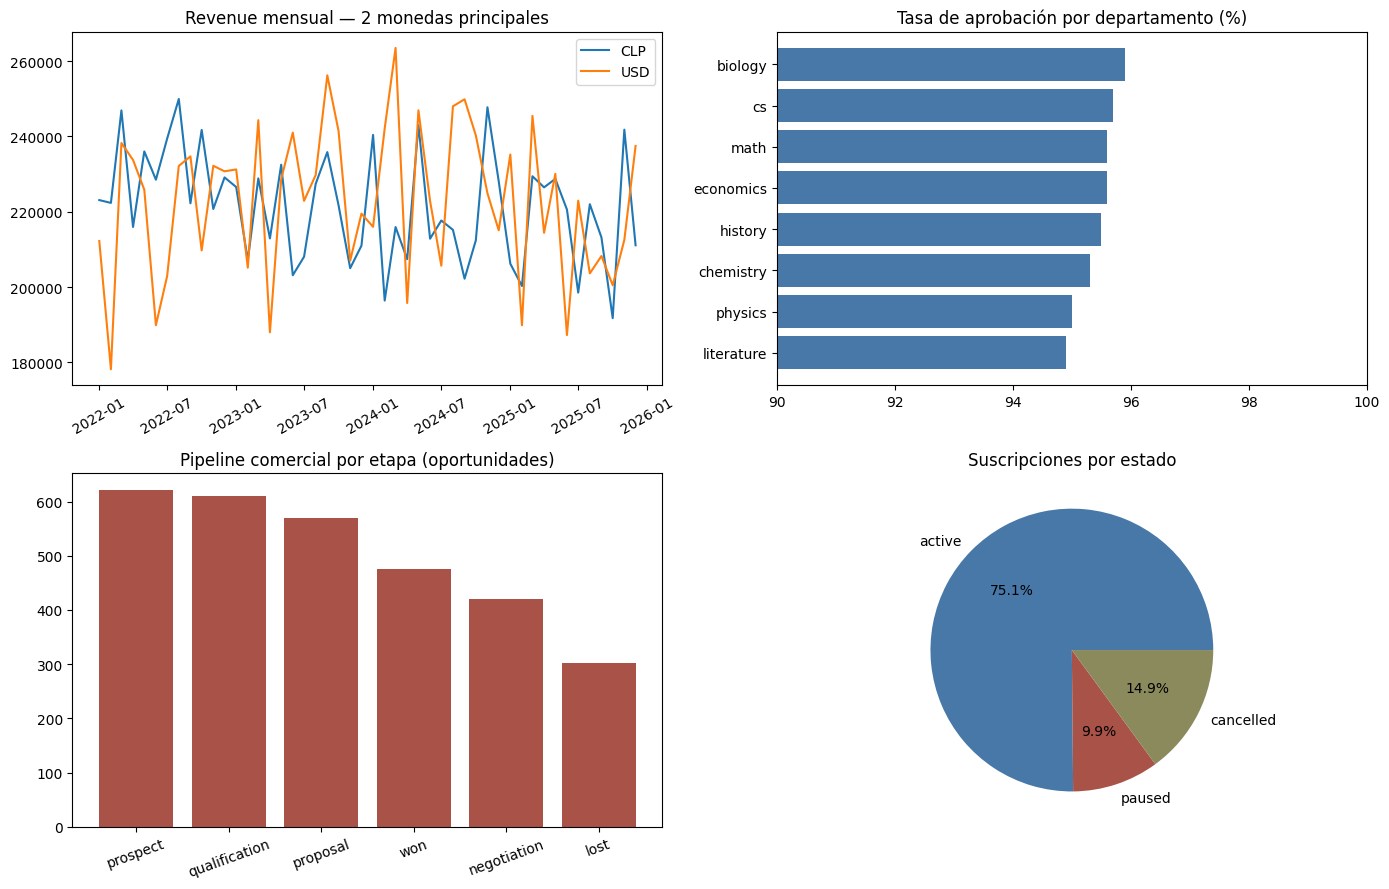

currency  invoices  billed_amount  paid_invoices  paid_pct
     USD     15162  10,694,119.88          10649     70.20
     CLP     15099  10,625,294.98          10575     70.00
     EUR      5000   3,571,433.35           3446     68.90
     MXN      4876   3,402,812.01           3420     70.10
     COP      2540   1,797,731.51           1779     70.00
     ARS      2456   1,783,643.42           1702     69.30
     BRL      2412   1,705,509.59           1642     68.10
     PEN      2455   1,697,618.83           1753     71.40


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

rev = q("""SELECT month, currency, revenue FROM gold.kpi_revenue_monthly
           WHERE currency IN ('USD', 'CLP') ORDER BY month""")
for cur, g in rev.groupby('currency'):
    axes[0, 0].plot(pd.to_datetime(g.month), g.revenue, label=cur)
axes[0, 0].set_title('Revenue mensual — 2 monedas principales')
axes[0, 0].legend(); axes[0, 0].tick_params(axis='x', rotation=30)

acad = q('SELECT department, pass_rate_pct FROM gold.kpi_academic_by_department ORDER BY 2')
axes[0, 1].barh(acad.department, acad.pass_rate_pct, color='#4878a8')
axes[0, 1].set_title('Tasa de aprobación por departamento (%)')
axes[0, 1].set_xlim(90, 100)

pipe = q('SELECT stage, opportunities FROM gold.kpi_sales_pipeline ORDER BY opportunities DESC')
axes[1, 0].bar(pipe.stage, pipe.opportunities, color='#a85248')
axes[1, 0].set_title('Pipeline comercial por etapa (oportunidades)')
axes[1, 0].tick_params(axis='x', rotation=20)

subs = q('SELECT status, subscriptions FROM gold.kpi_subscription_status')
axes[1, 1].pie(subs.subscriptions, labels=subs.status, autopct='%1.1f%%',
               colors=['#4878a8', '#a85248', '#8a8a5c'])
axes[1, 1].set_title('Suscripciones por estado')

fig.tight_layout(); plt.show()

print(q('SELECT * FROM gold.kpi_collection_by_currency ORDER BY billed_amount DESC').to_string(index=False))

**Lectura rápida:** cobranza ~70% pareja en las 8 monedas, aprobación 95–96% en todos los departamentos, win rate 61% sobre cerradas (476 won / 303 lost). Estas cifras "sanas" a primera vista esconden los hallazgos de la siguiente sección.

---

## 5. Insights ⭐

**Método:** minería sobre Gold en 4 frentes (revenue, suscripciones, académico, CRM/cross-dominio) con **verificación independiente de cada número** (queries re-escritas desde cero — 21/21 insights confirmados, 1 corrección menor). El detalle completo con acciones recomendadas está en [`docs/insights.md`](../docs/insights.md); aquí los 8 principales, con su evidencia calculada en vivo.

Los marcados 🎲 son patrones que delatan al generador sintético — se reportan igual: **detectar que un dato no discrimina también es un hallazgo**, y en producción sería una alerta automática de calidad.

### Insight 1 ⭐ — El MRR real es un tercio del reportado

,estado,suscripciones,mrr
0,activa vigente,4126,"194,673.58"
1,activa VENCIDA (end_date pasado),7146,"337,816.51"


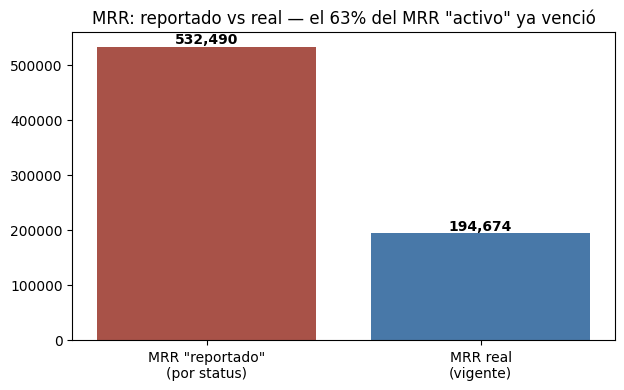

MRR inflado 2.7x. Vencidas hace >1 año: 3745


In [6]:
mrr = q("""
    SELECT CASE WHEN is_effectively_expired THEN 'activa VENCIDA (end_date pasado)'
                ELSE 'activa vigente' END AS estado,
           count(*) AS suscripciones, sum(monthly_price) AS mrr
    FROM gold.fact_subscription WHERE status = 'active' GROUP BY 1 ORDER BY 2""")
display(mrr)

nominal = mrr.mrr.sum(); real = mrr.loc[mrr.estado == 'activa vigente', 'mrr'].iloc[0]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['MRR "reportado"\n(por status)', 'MRR real\n(vigente)'], [nominal, real],
       color=['#a85248', '#4878a8'])
for i, v in enumerate([nominal, real]):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('MRR: reportado vs real — el 63% del MRR "activo" ya venció')
plt.show()
print(f'MRR inflado {nominal / real:.1f}x. Vencidas hace >1 año: '
      + str(q("""SELECT count(*) FROM gold.fact_subscription
                 WHERE status='active' AND is_effectively_expired
                   AND end_date < DATE '2025-07-20'""").iloc[0, 0]))

**Evidencia:** 7.146 de 11.272 suscripciones "activas" (63,4%) tienen `end_date` vencida. MRR nominal 532.490 → MRR real **194.674** (2,7× inflado); 3.745 contratos llevan más de un año vencidos sin cerrar ni renovar (5.038 vencieron en 2024–2025).

**Interpretación:** cualquier dashboard que sume por status proyecta casi el triple del revenue recurrente real. Es higiene operativa del billing: nadie actualiza el status contra el vencimiento.

**Acción:** KPI oficial de MRR = activas **no vencidas**; campaña de renovación empezando por los 1.525 contratos vencidos en 2026 (73K de MRR recuperable, vencimiento reciente). Complemento: el "libro perdido" (2.242 canceladas + 1.486 pausadas = 173,1K de MRR) casi iguala al MRR vivo — las pausadas son el objetivo de reactivación más barato.

### Insight 2 ⭐ — 30% de lo facturado está en la calle, con ~2,5 años de mora 🎲

,anio,facturas,abiertas,pct_abierta
0,2022,12497,3724,29.80
1,2023,12496,3809,30.50
2,2024,12547,3782,30.10
3,2025,12460,3719,29.80


,currency,monto_abierto,mora_media_dias
0,USD,"3,206,972.19",896.00
1,CLP,"3,114,776.65",906.00
2,EUR,"1,124,423.54",885.00
3,MXN,"1,036,083.91",901.00


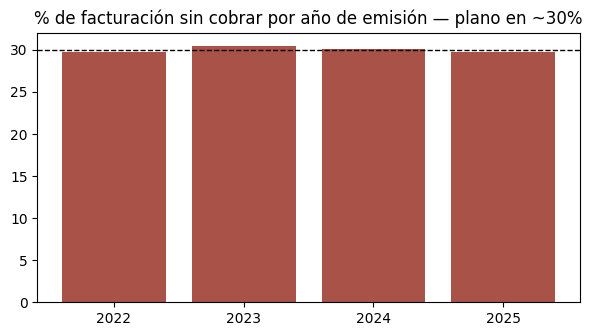

In [7]:
mora = q("""
    SELECT extract(year FROM issued_date)::int AS anio,
           count(*) AS facturas,
           count(*) FILTER (WHERE status <> 'paid') AS abiertas,
           round(100.0 * count(*) FILTER (WHERE status <> 'paid') / count(*), 1) AS pct_abierta
    FROM gold.fact_invoice GROUP BY 1 ORDER BY 1""")
display(mora)

montos = q("""
    SELECT currency, sum(invoiced_amount) FILTER (WHERE status <> 'paid') AS monto_abierto,
           round(avg(DATE '2026-07-20' - due_date) FILTER (WHERE status <> 'paid')) AS mora_media_dias
    FROM gold.fact_invoice GROUP BY 1 ORDER BY 2 DESC NULLS LAST""")
display(montos.head(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(mora.anio.astype(str), mora.pct_abierta, color='#a85248')
ax.axhline(30, color='black', linestyle='--', linewidth=1)
ax.set_title('% de facturación sin cobrar por año de emisión — plano en ~30%')
plt.show()

**Evidencia:** 15.034 facturas abiertas (30,1%), USD 3,2M + CLP 3,1M sin cobrar, mora media ~900 días. El % es casi idéntico por año (29,8–30,5%): **3.724 facturas de 2022 siguen abiertas al snapshot**.

**Interpretación:** no existe proceso de cobranza ni castigo — cuentas por cobrar de 2,5 años inflan el activo. (La uniformidad perfecta del 30% delata al generador 🎲, pero la ausencia de aging es el mensaje operativo real.)

**Acción:** dunning automático a 30/60/90 días; provisión/castigo de lo vencido >365 días; KPI de cobranza por cohorte de emisión.

### Insight 3 — La pirámide de revenue está invertida: el tier más barato sostiene el negocio

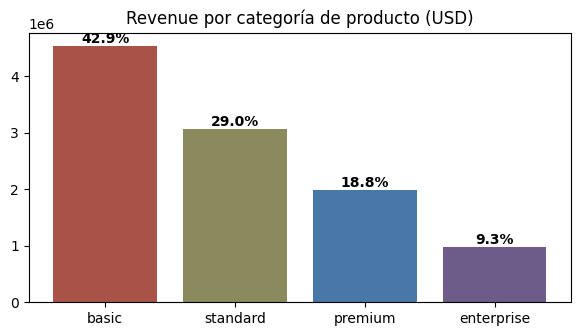

Orden de categorías por moneda (las 8 deberían coincidir):
currency
ARS    basic > standard > premium > enterprise
BRL    basic > standard > premium > enterprise
CLP    basic > standard > premium > enterprise
COP    basic > standard > premium > enterprise
EUR    basic > standard > premium > enterprise
MXN    basic > standard > premium > enterprise
PEN    basic > standard > premium > enterprise
USD    basic > standard > premium > enterprise


In [8]:
mix = q("""
    SELECT f.currency, p.category, sum(i.quantity * i.unit_price) AS revenue
    FROM silver.billing_invoice_items i
    JOIN silver.billing_products p USING (product_id)
    JOIN silver.billing_invoices f USING (invoice_id)
    GROUP BY 1, 2""")

usd = mix[mix.currency == 'USD'].sort_values('revenue', ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(usd.category, usd.revenue, color=['#a85248', '#8a8a5c', '#4878a8', '#6d5c8a'])
for i, (cat, v) in enumerate(zip(usd.category, usd.revenue)):
    ax.text(i, v, f'{100 * v / usd.revenue.sum():.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Revenue por categoría de producto (USD)')
plt.show()

orden_por_moneda = (mix.sort_values('revenue', ascending=False)
                       .groupby('currency')['category'].apply(lambda s: ' > '.join(s)))
print('Orden de categorías por moneda (las 8 deberían coincidir):')
print(orden_por_moneda.to_string())

**Evidencia:** basic 42,9% > standard 29,0% > premium 18,8% > enterprise 9,3% (USD) — y el **mismo orden se repite en las 8 monedas**.

**Interpretación:** en un negocio por suscripción esperarías lo inverso. O el pricing de los tiers altos no es competitivo, o nadie está migrando clientes hacia arriba. Además el ticket por segmento de cliente es plano (~700 USD para retail, smb y enterprise): la segmentación no monetiza.

**Acción:** un solo playbook global de upsell basic→standard/premium (el patrón es idéntico en todas las plazas); revisar el empaquetado enterprise (<10% del revenue en todas las monedas).

### Insight 4 — Revenue estancado 4 años, sin estacionalidad 🎲

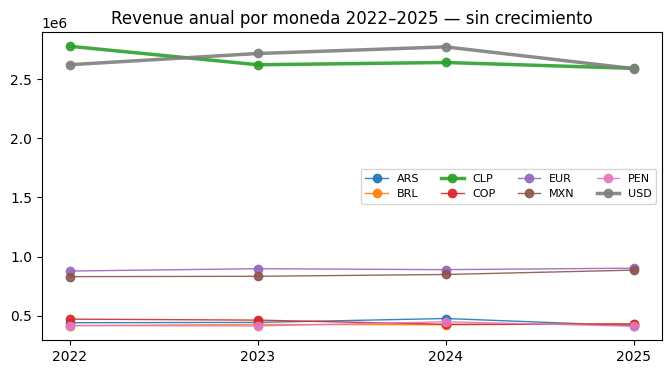

USD 2025 vs 2022: -1.3% | vs pico 2024: -6.6%


In [9]:
anual = q("""
    SELECT extract(year FROM issued_date)::int AS anio, currency,
           sum(invoiced_amount) AS revenue
    FROM gold.fact_invoice GROUP BY 1, 2 ORDER BY 1""")
fig, ax = plt.subplots(figsize=(8, 4))
for cur, g in anual.groupby('currency'):
    ax.plot(g.anio, g.revenue, marker='o', label=cur,
            linewidth=2.5 if cur in ('USD', 'CLP') else 1, alpha=0.9)
ax.set_title('Revenue anual por moneda 2022–2025 — sin crecimiento')
ax.legend(ncol=4, fontsize=8); ax.set_xticks([2022, 2023, 2024, 2025])
plt.show()

usd_a = anual[anual.currency == 'USD'].set_index('anio').revenue
print(f"USD 2025 vs 2022: {100 * (usd_a[2025] / usd_a[2022] - 1):+.1f}% | "
      f"vs pico 2024: {100 * (usd_a[2025] / usd_a[2024] - 1):+.1f}%")

**Evidencia:** USD −1,3% en 4 años (−6,6% vs pico 2024); CLP −6,7%; solo EUR/MXN crecen marginalmente. Sin patrón estacional mensual.

**Interpretación:** el negocio no crece, y las dos plazas principales se contraen en 2025. Combinado con el Insight 3, el caso de crecimiento es upsell sobre la base existente, no estacionalidad ni adquisición.

### Insight 5 ⭐ — Cold call convierte 1,7× mejor que web; el lead score es ruido

,source,leads,convertidos,conv_pct
0,cold_call,204,30,14.70
1,referral,402,46,11.40
2,event,302,32,10.60
3,ads,282,28,9.90
4,web,810,69,8.50


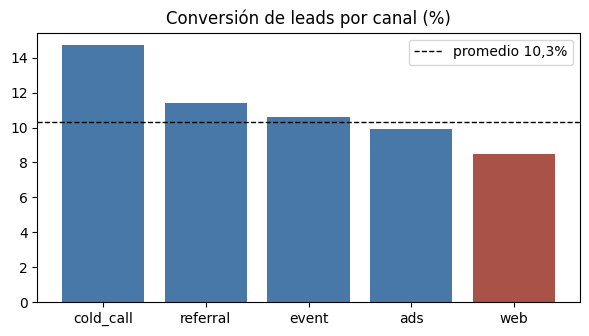

 is_converted  score_promedio  count
        False           50.00   1795
         True           50.80    205


In [10]:
leads = q("""
    SELECT source, count(*) AS leads,
           count(*) FILTER (WHERE status = 'converted') AS convertidos,
           round(100.0 * count(*) FILTER (WHERE status = 'converted') / count(*), 1) AS conv_pct
    FROM gold.fact_lead GROUP BY 1 ORDER BY conv_pct DESC""")
display(leads)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#4878a8' if s != 'web' else '#a85248' for s in leads.source]
ax.bar(leads.source, leads.conv_pct, color=colors)
ax.axhline(10.3, color='black', linestyle='--', linewidth=1, label='promedio 10,3%')
ax.set_title('Conversión de leads por canal (%)'); ax.legend()
plt.show()

score = q("""SELECT is_converted, round(avg(score), 1) AS score_promedio, count(*)
             FROM gold.fact_lead GROUP BY 1""")
print(score.to_string(index=False))

**Evidencia:** cold_call 14,7% > referral 11,4% > event 10,6% > ads 9,9% > **web 8,5%** — y web aporta el 40% del volumen. Score promedio de convertidos 50,8 vs no convertidos 50,0: **el scoring no discrimina en absoluto**.

**Interpretación:** el canal más caro de ignorar: el de mayor volumen es el que peor convierte, y el modelo de priorización actual es ruido puro. Priorizar por canal es hoy más efectivo que priorizar por score. (n de cold_call = 204: la ventaja es direccional.)

**Acción:** reasignar presupuesto hacia contacto directo o mejorar la calificación del tráfico web; reconstruir el lead scoring desde cero.

### Insight 6 ⭐ — 1.303 inscripciones "aprobadas" sin ninguna nota (8,7%)

,semestre,completed,sin_notas,pct
0,2022-1,1895,160,8.44
1,2022-2,1909,172,9.01
2,2023-1,1866,172,9.22
3,2023-2,1799,160,8.89
4,2024-1,1795,167,9.30
5,2024-2,1916,168,8.77
6,2025-1,1785,147,8.24
7,2025-2,1966,157,7.99


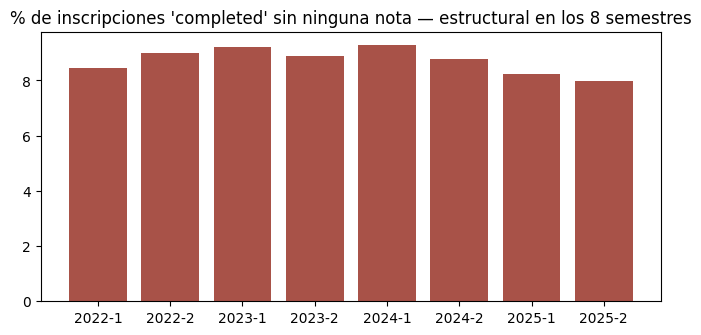

Total: 1,303 de 14,931 (8.73%)


In [11]:
actas = q("""
    SELECT s.code AS semestre,
           count(*) FILTER (WHERE e.status = 'completed') AS completed,
           count(*) FILTER (WHERE e.status = 'completed' AND NOT e.has_grades) AS sin_notas,
           round(100.0 * count(*) FILTER (WHERE e.status = 'completed' AND NOT e.has_grades)
                 / NULLIF(count(*) FILTER (WHERE e.status = 'completed'), 0), 2) AS pct
    FROM silver.university_enrollments e
    JOIN silver.university_semesters s USING (semester_id)
    GROUP BY 1 ORDER BY 1""")
display(actas)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(actas.semestre, actas.pct, color='#a85248')
ax.set_title("% de inscripciones 'completed' sin ninguna nota — estructural en los 8 semestres")
plt.show()
print(f"Total: {actas.sin_notas.sum():,} de {actas.completed.sum():,} "
      f"({100 * actas.sin_notas.sum() / actas.completed.sum():.2f}%)")

**Evidencia:** 1.303 de 14.931 `completed` (8,73%) sin ninguna evaluación registrada, presente en los 8 semestres (7,99%–9,31%).

**Interpretación:** brecha administrativa estructural — 1 de cada 11 cursos "aprobados" no tiene respaldo académico. No es un semestre puntual: es el proceso de cierre de actas.

**Acción:** regla en origen: no cerrar `completed` sin al menos una nota; regularizar el backlog de 1.303 actas por semestre.

### Insight 7 — Pérdida académica estancada en ~20% durante 4 años

,anio,pct_perdida,dropped,failed
0,2022,20.30,644,646
1,2023,20.24,630,615
2,2024,20.08,598,643
3,2025,19.88,628,622


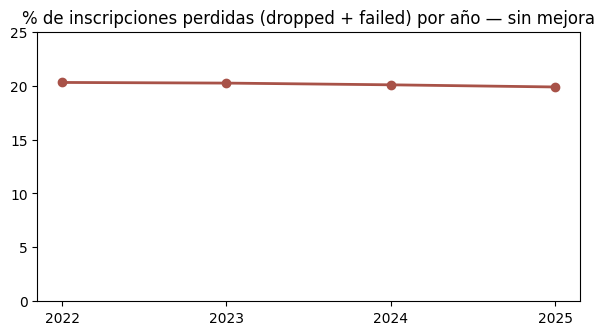

In [12]:
perdida = q("""
    SELECT s.year AS anio,
           round(100.0 * count(*) FILTER (WHERE f.status IN ('dropped', 'failed'))
                 / count(*), 2) AS pct_perdida,
           count(*) FILTER (WHERE f.status = 'dropped') AS dropped,
           count(*) FILTER (WHERE f.status = 'failed') AS failed
    FROM gold.fact_enrollment f
    JOIN gold.dim_semester s USING (semester_id)
    GROUP BY 1 ORDER BY 1""")
display(perdida)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(perdida.anio, perdida.pct_perdida, marker='o', color='#a85248', linewidth=2)
ax.set_ylim(0, 25); ax.set_xticks(perdida.anio)
ax.set_title('% de inscripciones perdidas (dropped + failed) por año — sin mejora')
plt.show()

**Evidencia:** 20,30% (2022) → 19,88% (2025): una caída de solo 0,4 pts en 4 años. Mitad abandono, mitad reprobación.

**Interpretación:** 1 de cada 5 inscripciones se pierde y ninguna iniciativa movió la aguja. Dato honesto adicional 🎲: las notas no explican el fenómeno (un "failed" promedia 74,55 vs 74,90 de un "completed" — el status está desacoplado de las notas en este dataset).

**Acción:** fijar 20% como línea base con meta explícita; alerta temprana sobre las ~5.000 `active` del semestre en curso.

### Insight 8 — El desempeño comercial varía por industria; el ciclo de venta no es reportable 🎲

,industry,cerradas,win_rate
0,finance,90,68.90
1,energy,61,62.30
2,tech,144,61.80
3,services,72,61.10
4,manufacturing,82,61.00
5,retail,142,59.20
6,health,109,58.70
7,education,79,57.00


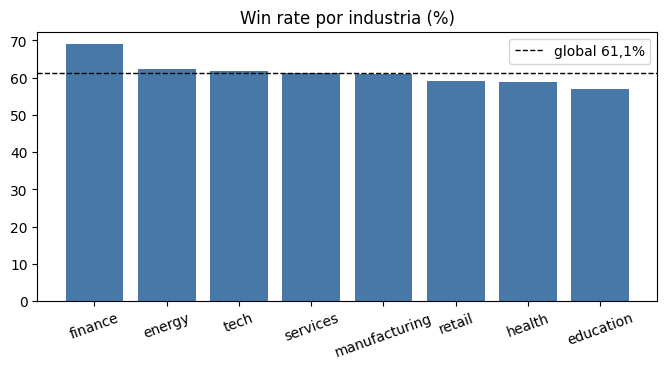

 cerradas  fechas_rotas  ciclo_mediano_dias
      779           270              542.00


In [13]:
win = q("""
    SELECT a.industry,
           count(*) FILTER (WHERE o.is_closed) AS cerradas,
           round(100.0 * count(*) FILTER (WHERE o.is_won)
                 / NULLIF(count(*) FILTER (WHERE o.is_closed), 0), 1) AS win_rate
    FROM gold.fact_opportunity o
    JOIN gold.dim_account a USING (account_id)
    GROUP BY 1 HAVING count(*) FILTER (WHERE o.is_closed) > 0
    ORDER BY win_rate DESC""")
display(win)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(win.industry, win.win_rate, color='#4878a8')
ax.axhline(61.1, color='black', linestyle='--', linewidth=1, label='global 61,1%')
ax.set_title('Win rate por industria (%)'); ax.legend(); ax.tick_params(axis='x', rotation=20)
plt.show()

ciclo = q("""
    SELECT count(*) FILTER (WHERE is_closed) AS cerradas,
           count(*) FILTER (WHERE is_closed AND is_close_before_created) AS fechas_rotas,
           round(percentile_cont(0.5) WITHIN GROUP (ORDER BY close_date - created_date)
                 FILTER (WHERE is_closed AND NOT is_close_before_created)) AS ciclo_mediano_dias
    FROM gold.fact_opportunity""")
print(ciclo.to_string(index=False))

**Evidencia:** finance 68,9% vs education 57,0% (global 61,1%); los deals perdidos son en promedio *más grandes* que los ganados (39.409 vs 38.573) — no se pierde por perseguir deals chicos. Y **270 de 779 cierres (34,7%) tienen `close_date` anterior a `created_at`**: el ciclo de venta mediano de 542 días sobre las fechas válidas tampoco describe un proceso real 🎲.

**Interpretación:** hay señal direccional por industria (muestras chicas: finance n=90), pero **hoy no se puede afirmar cuánto tarda un deal en cerrarse** — un tercio del pipeline tiene fechas imposibles. Además, el 14,9% de las actividades comerciales es huérfano (no atribuible) y el volumen de toques no distingue won de lost (3,27 vs 3,29 por oportunidad).

**Acción:** bloquear el KPI de ciclo en el dashboard hasta validar `close_date >= created_at` en origen; replicar el playbook de finance en education/health; vinculación obligatoria de actividades en el CRM.

### Bonus cross-dominio — Ser estudiante no cambia el comportamiento de pago 🎲

In [14]:
print(q('SELECT * FROM gold.kpi_student_vs_external').to_string(index=False))

customer_type  customers  invoices  invoices_per_customer  revenue_per_customer
   estudiante       5000     25071                   5.01              3,534.79
      externo       5000     24929                   4.99              3,520.85


**Evidencia:** revenue por cliente: estudiantes 3.534,79 vs externos 3.520,85 (+0,4%). El único puente confiable entre dominios (`customers.external_ref` → `students.student_id`, 1:1, 0 huérfanos) permite esta comparación — y da una conclusión honesta: **no hay diferencia que monetizar**. Vale más que un hallazgo espurio: evita invertir en una segmentación sin retorno.

---

## 6. Conclusiones y mejoras futuras

### Conclusiones

1. **El pipeline cumple su promesa end-to-end:** 446.708 filas ingeridas con evidencia (checksums, batches), limpiadas con 20+ reglas explícitas (flags, no borrado), modeladas en estrella y validadas con 83+ comprobaciones automáticas por capa — todo reejecutable con un trigger de Airflow sin duplicar datos.
2. **El mayor valor de negocio salió de la calidad de datos, no de los KPIs "sanos":** el MRR real es un tercio del reportado, el 30% de la facturación está en la calle sin proceso de cobranza, y 6.035 facturas no tienen respaldo documental. Un dashboard ingenuo sobre los datos crudos habría reportado un negocio 3× más sano de lo real.
3. **La honestidad analítica es un entregable:** varios patrones (notas ~N(75), status desacoplado de notas, fechas de CRM imposibles) delatan al generador sintético. Se reportan como tales — en producción serían alertas automáticas de calidad, y saber que un dato *no discrimina* previene decisiones sobre ruido (rankings académicos, lead scoring).

### Mejoras futuras

- **Validación en origen:** bloquear facturas sin items, `paid` sin pago, `close_date < created_at`, actas `completed` sin notas y pesos que no suman 100% — hoy el pipeline los detecta *a posteriori*; lo ideal es impedirlos *a priori*.
- **Tipo de cambio:** incorporar una tabla de FX para consolidar revenue multi-moneda (hoy, correctamente, no se suma).
- **Orquestación:** pasar el DAG a schedule diario con sensores de llegada de archivos, alertas (email/Slack) en fallos de gates, y SLAs por tarea.
- **Modelado:** SCD tipo 2 en dimensiones que cambian (productos, cuentas), y un `dim_person` conformado si algún día existe un identificador cross-dominio real (hoy el matching por email/nombre sería espurio: 0/5.000 coincidencias).
- **Dashboard:** exponer los KPIs de *calidad* (flags por capa) junto a los de negocio en Superset, para que la salud del dato sea visible al mismo nivel que el revenue.